[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/finetuning/blob/main/chapter_08/listing_8.1.ipynb)

In [1]:
import sys
if 'google.colab' in sys.modules:
    pass
    # !pip install evaluate

### Listing 6.1: Environment Setup and Hardware Configuration

In [2]:
import os
import torch
import warnings
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import EarlyStoppingCallback
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float32
elif torch.backends.mps.is_available():
    device = "mps"
    compute_dtype = torch.bfloat16
else:
    device = "cpu"
    compute_dtype = torch.float32
print(f"Using device: {device} | Dtype: {compute_dtype}")

Using device: cuda | Dtype: torch.bfloat16


### Listing 6.2: Loading and Formatting the FinancialPhraseBank Dataset

In [3]:
DATASET_ID = "lmassaron/FinancialPhraseBank_explained"
print(f"Loading {DATASET_ID}...")
dataset = load_dataset(DATASET_ID)

dataset = dataset.rename_columns({"sentence": "text", "explanation": "reasoning"})
train_ds = dataset["train"]
eval_ds = dataset["validation"]
print(train_ds)
print("Sample sentence:", train_ds[0]["text"])
print("Sample sentiment:", train_ds[0]["sentiment"])
print("Sample explanation:", train_ds[0]["reasoning"])

Loading lmassaron/FinancialPhraseBank_explained...
Dataset({
    features: ['text', 'label', 'sentiment', 'reasoning', 'is_augmented', 'judge_score'],
    num_rows: 7902
})
Sample sentence: The shares carry a right to dividend and other shareholder rights as from their registration with the Finnish Trade Register .
Sample sentiment: neutral
Sample explanation: The inclusion of a right to dividend and other shareholder rights indicates that the shares have reached a status where they are eligible for dividends and certain voting rights. This typically does not directly impact revenue or profitability but can enhance investor confidence by providing clear entitlements and potentially increasing the perceived value of the shares, thus maintaining a neutral sentiment in terms of market reaction.


### Listing 6.3: Defining the System Prompt and Applying the Chat Template

In [4]:
SYSTEM_PROMPT = (
    "You are a financial analyst with expertise in equity markets and corporate finance.\n"
    "Analyze the following financial news headline and determine its market sentiment "
    "from an investor's perspective.\n\n"
    "Classify the sentiment as positive, neutral, or negative based on the likely "
    "impact on stock price, investor confidence, or financial performance.\n\n"
    "Respond using exactly these two tags:\n"
    "<sentiment>positive|neutral|negative</sentiment>\n"
    "<reasoning>brief financial explanation</reasoning>\n"
)

MODEL_ID = "google/gemma-4-E2B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def format_prompt(example):
    messages = [
        {"role": "user", "content": SYSTEM_PROMPT + f'\nHeadline: "{example["text"]}"'},
        {
            "role": "assistant",
             "content": f"<sentiment>{example['sentiment']}</sentiment>\n"
             "<reasoning>{example['reasoning']}</reasoning>",
        },
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": prompt}

train_mapped = train_ds.map(format_prompt)
eval_mapped = eval_ds.map(format_prompt)
print("Mapped Prompt Preview:\n", train_mapped[0]["text"])

Mapped Prompt Preview:
 <bos><|turn>user
You are a financial analyst with expertise in equity markets and corporate finance.
Analyze the following financial news headline and determine its market sentiment from an investor's perspective.

Classify the sentiment as positive, neutral, or negative based on the likely impact on stock price, investor confidence, or financial performance.

Respond using exactly these two tags:
<sentiment>positive|neutral|negative</sentiment>
<reasoning>brief financial explanation</reasoning>

Headline: "The shares carry a right to dividend and other shareholder rights as from their registration with the Finnish Trade Register ."<turn|>
<|turn>model
<sentiment>neutral</sentiment>
<reasoning>{example['reasoning']}</reasoning><turn|>



### Listing 6.4: Configuring 4-Bit Quantization and LoRA Adapters

In [5]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=quant_config, device_map="auto"
)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules="all-linear",
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

### Listing 6.5: Initializing the SFTTrainer and Executing Fine-Tuning

In [6]:
training_args = SFTConfig(
    output_dir="gemma4-sentiment-lora",
    dataset_text_field="text",
    max_length=512,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    optim="adamw_torch_fused",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    lr_scheduler_type="cosine",
    warmup_steps=0,
    bf16=(compute_dtype == torch.bfloat16),
    logging_steps=100,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=100,
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to="none",
    dataset_kwargs={
        "add_special_tokens": False,
    },
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_mapped,
    eval_dataset=eval_mapped,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

model.config.use_cache = False

trainer.train()

trainer.model.save_pretrained("gemma4-sentiment-lora-adapter")
tokenizer.save_pretrained("gemma4-sentiment-lora-adapter")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.801202,0.612044,0.567748,127429.000000,0.884407
200,0.583635,0.591523,0.598300,254350.000000,0.887273
300,0.559742,0.580779,0.539353,381250.000000,0.888683
400,0.571315,0.571839,0.580967,508075.000000,0.889837
500,0.540431,0.564600,0.568582,634862.000000,0.890825
600,0.553319,0.558268,0.547097,762180.000000,0.891137
700,0.524945,0.553218,0.515992,889220.000000,0.891867
800,0.549272,0.547102,0.575225,1017803.000000,0.893170
900,0.521396,0.542496,0.539692,1144987.000000,0.893505
1000,0.526913,0.543428,0.485502,1272085.000000,0.893117


('gemma4-sentiment-lora-adapter/tokenizer_config.json',
 'gemma4-sentiment-lora-adapter/chat_template.jinja',
 'gemma4-sentiment-lora-adapter/tokenizer.json')

### Listing 6.6: Visualizing Training Metrics and Loss Curves

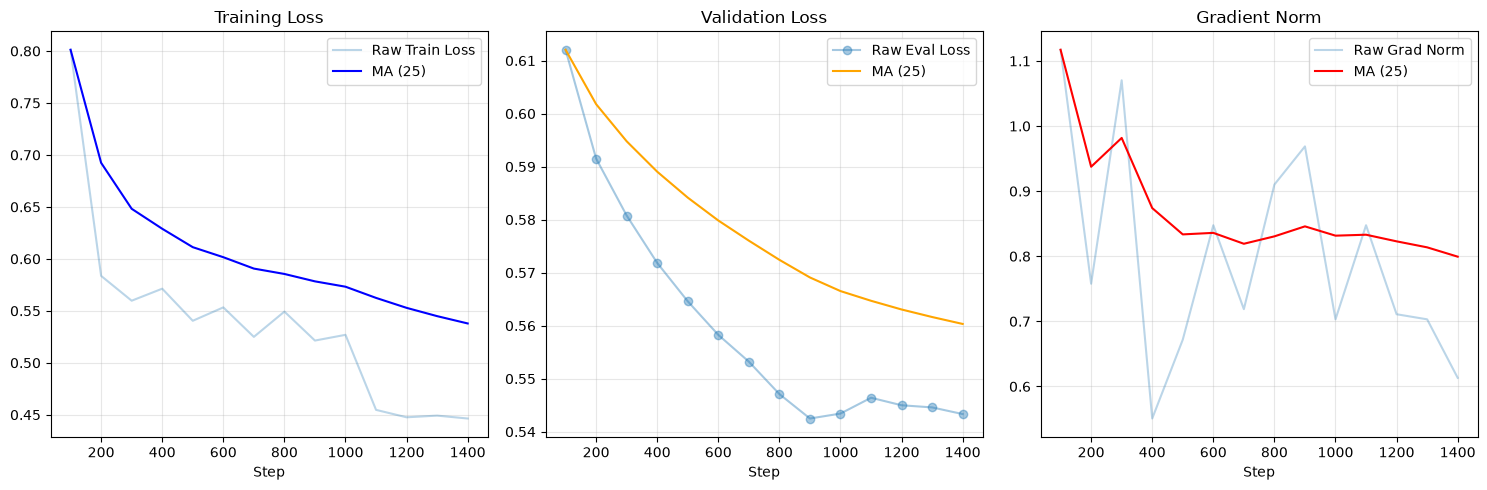

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_metrics(
    log_history, 
    window=25, 
    save_path="training_curves.png", 
    figsize=(15, 5), 
    dpi=150
):
    """Extracts and plots training loss, validation loss, and gradient norm with a moving average"""

    logs = pd.DataFrame(log_history)
    
    if "step" not in logs.columns:
        raise ValueError("Log history must contain a 'step' column.")
        
    logs = logs[logs["step"].notna()].copy()
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    if "loss" in logs:
        train_logs = logs[logs["loss"].notna()].copy()
        train_logs["loss_ma"] = train_logs["loss"].rolling(window=window, min_periods=1).mean()
        axes[0].plot(train_logs["step"], train_logs["loss"], alpha=0.3, label="Raw Train Loss")
        axes[0].plot(train_logs["step"], train_logs["loss_ma"], color="blue", label=f"MA ({window})")
        axes[0].set_title("Training Loss")
        axes[0].legend()

    if "eval_loss" in logs:
        eval_logs = logs[logs["eval_loss"].notna()].copy()
        if not eval_logs.empty:
            eval_logs["eval_loss_ma"] = eval_logs["eval_loss"].rolling(window=window, min_periods=1).mean()
            # Added markers because eval steps are usually logged less frequently
            axes[1].plot(eval_logs["step"], eval_logs["eval_loss"], alpha=0.4, marker='o', label="Raw Eval Loss")
            axes[1].plot(eval_logs["step"], eval_logs["eval_loss_ma"], color="orange", label=f"MA ({window})")
            axes[1].set_title("Validation Loss")
            axes[1].legend()
        else:
            axes[1].set_title("Validation Loss (No Data)")

    if "grad_norm" in logs:
        grad_logs = logs[logs["grad_norm"].notna()].copy()
        grad_logs["grad_norm_ma"] = grad_logs["grad_norm"].rolling(window=window, min_periods=1).mean()
        axes[2].plot(grad_logs["step"], grad_logs["grad_norm"], alpha=0.3, label="Raw Grad Norm")
        axes[2].plot(grad_logs["step"], grad_logs["grad_norm_ma"], color="red", label=f"MA ({window})")
        axes[2].set_title("Gradient Norm")
        axes[2].legend()

    for ax in axes.flat:
        ax.set_xlabel("Step")
        ax.grid(alpha=0.3)

    plt.tight_layout()
  
    if save_path:
        plt.savefig(save_path, dpi=dpi)      
    plt.show()
    return fig, axes

_ = plot_training_metrics(trainer.state.log_history)

### Listing 6.7: Reloading the Fine-Tuned LoRA Adapter for Inference

In [8]:
from peft import PeftModel
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import re
import pandas as pd

eval_model = PeftModel.from_pretrained(model, "gemma4-sentiment-lora-adapter")
eval_model = eval_model.eval()

### Listing 6.8: Preparing Test Data and Generating Responses

In [9]:
test_df = dataset["test"].to_pandas()
if "is_augmented" in test_df.columns:
    test_df = test_df[test_df["is_augmented"] == False].reset_index(drop=True)
print(f"Evaluating on {len(test_df)} original test headlines.")

tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def extract_tag(text, tag):
    match = re.search(rf"<{tag}>(.*?)</{tag}>", text, re.IGNORECASE | re.DOTALL)
    return match.group(1).strip() if match else None

results = []
batch_size = 16

for start in tqdm(range(0, len(test_df), batch_size), desc="Evaluating"):
    batch_df = test_df.iloc[start : start + batch_size]
    prompts = [
        tokenizer.apply_chat_template(
            [{"role": "user", "content": SYSTEM_PROMPT + f'Headline: "{row["text"]}"'}],
            tokenize=False, add_generation_prompt=True,
        )
        for _, row in batch_df.iterrows()
    ]

    inputs = tokenizer(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=512
    ).to(eval_model.device)

    with torch.no_grad():
        outputs = eval_model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    input_len = inputs["input_ids"].shape[1]
    decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)

    for i, raw_output in enumerate(decoded):
        sentiment_tag = extract_tag(raw_output, "sentiment")
        reasoning_pred = extract_tag(raw_output, "reasoning")
        results.append(
            {
                "sentiment_true": batch_df.iloc[i]["sentiment"],
                "sentiment_pred": sentiment_tag.lower() if sentiment_tag else "neutral",
                "reasoning_pred": reasoning_pred if reasoning_pred else "none",
                "tag_integrity": sentiment_tag is not None
                and reasoning_pred is not None,
            }
        )

Evaluating on 484 original test headlines.


Evaluating: 100%|██████████| 31/31 [00:53<00:00,  1.74s/it]


### Listing 6.9: Extracting Tags and Scoring Performance

In [10]:
results_df = pd.DataFrame(results)
accuracy = accuracy_score(results_df["sentiment_true"], results_df["sentiment_pred"])
integrity = results_df["tag_integrity"].mean()
print(f"\nAccuracy: {accuracy:.2%}")
print(f"Tag Integrity: {integrity:.2%}")
print("\nClassification Report:")
print(classification_report(results_df["sentiment_true"], results_df["sentiment_pred"]))


Accuracy: 86.16%
Tag Integrity: 95.66%

Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.77      0.85        61
     neutral       0.83      0.96      0.89       287
    positive       0.90      0.69      0.78       136

    accuracy                           0.86       484
   macro avg       0.90      0.81      0.84       484
weighted avg       0.87      0.86      0.86       484

